[*********************100%***********************]  6 of 6 completed
/tmp/ipykernel_7638/3306846466.py:26: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


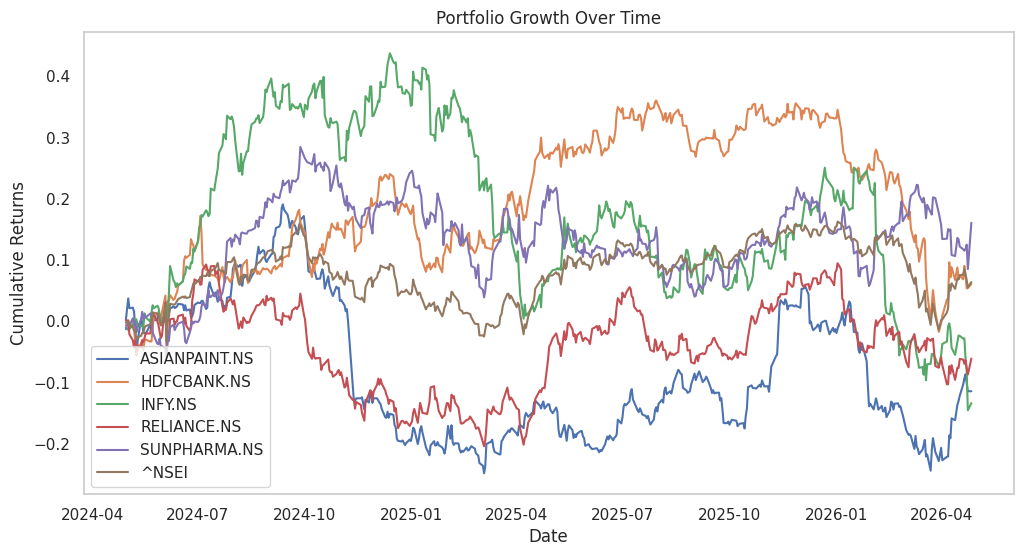

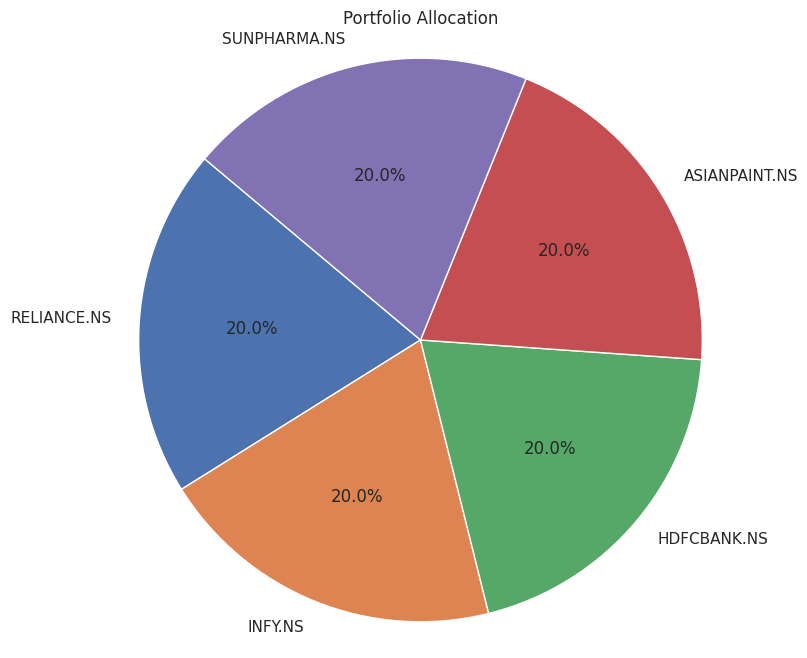

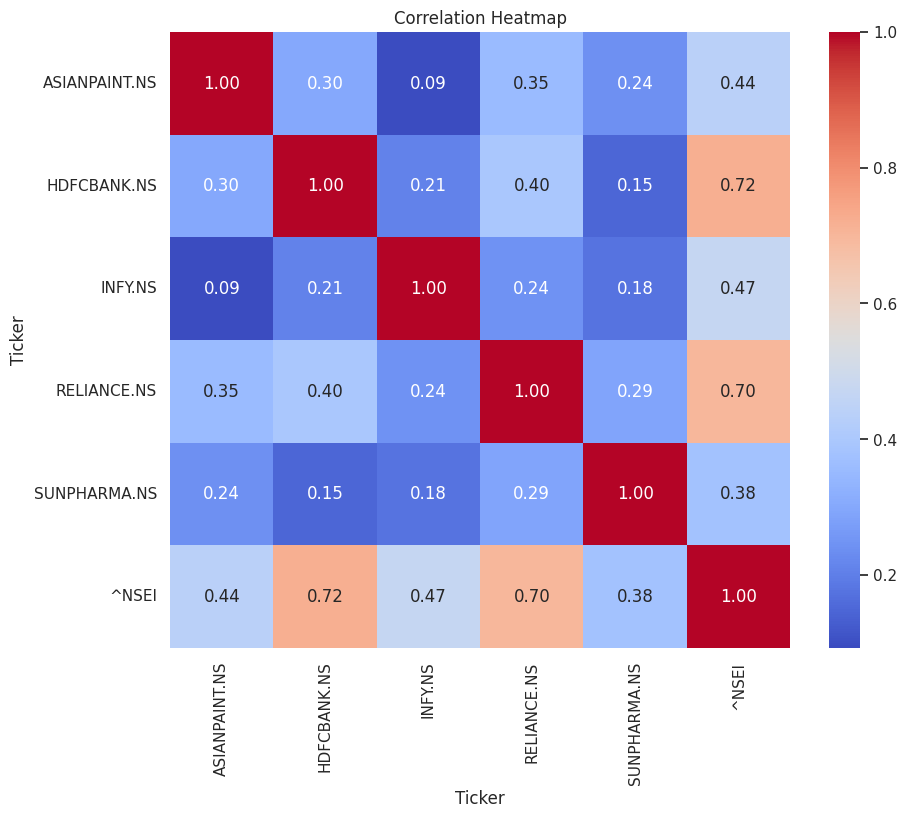

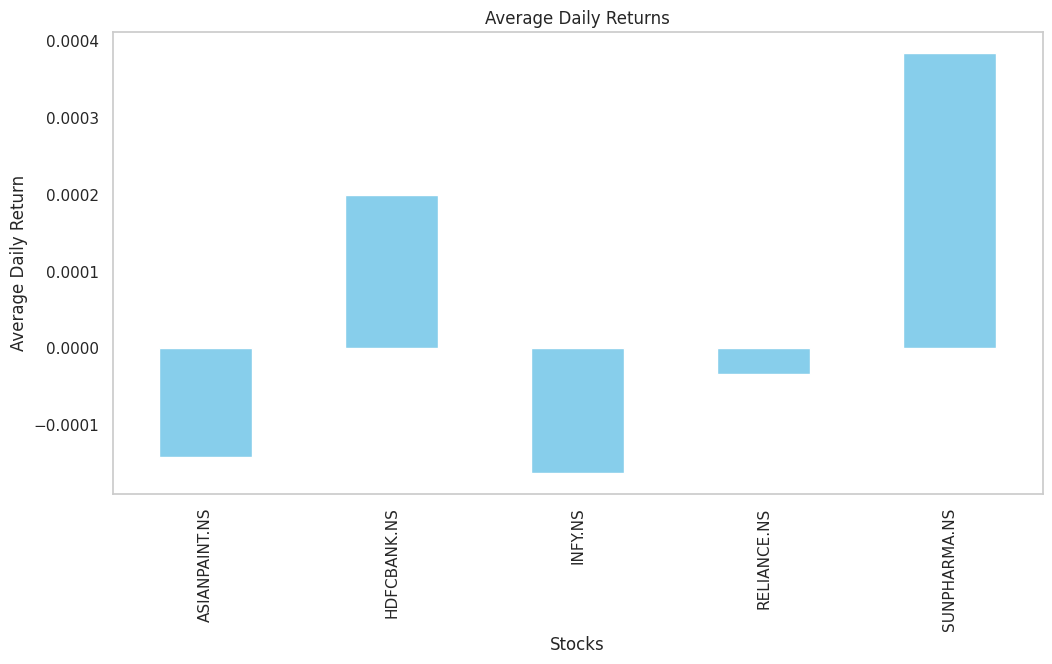

                   CAGR  Sharpe Ratio      Beta  Standard Deviation
Ticker                                                             
ASIANPAINT.NS -0.058822     -0.377327  0.701387            0.227893
HDFCBANK.NS    0.030053      0.000794  1.012301            0.199401
INFY.NS       -0.069205     -0.358461  0.840917            0.253970
RELIANCE.NS   -0.030892     -0.268871  1.072442            0.217409
SUNPHARMA.NS   0.077516      0.230986  0.538985            0.202745
^NSEI          0.031506     -0.057928       NaN            0.141880


In [7]:
!pip install yfinance --upgrade

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

# Set the style for plots
sns.set(style="whitegrid")

# Define the stock symbols and benchmark
stocks = ['RELIANCE.NS', 'INFY.NS', 'HDFCBANK.NS', 'ASIANPAINT.NS', 'SUNPHARMA.NS']
benchmark = '^NSEI'  # Nifty 50

# Define the time period for the analysis
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=2)

# Download stock data
data = yf.download(stocks + [benchmark], start=start_date, end=end_date)['Close']

# Calculate daily returns
returns = data.pct_change().dropna()

# Calculate cumulative returns
cumulative_returns = (1 + returns).cumprod() - 1

# Calculate CAGR
cagr = (cumulative_returns.iloc[-1] + 1) ** (1 / 2) - 1

# Calculate Sharpe Ratio (assuming risk-free rate of 0.05)
risk_free_rate = 0.05
sharpe_ratio = (returns.mean() * 252 - risk_free_rate) / (returns.std() * np.sqrt(252))

# Calculate Beta
cov_matrix = returns.cov()
benchmark_var = returns[benchmark].var()
beta = cov_matrix[benchmark].iloc[:-1] / benchmark_var

# Calculate standard deviation
std_dev = returns.std() * np.sqrt(252)

# Calculate correlation
correlation = returns.corr()

# Plot portfolio growth chart
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns)
plt.title('Portfolio Growth Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend(cumulative_returns.columns)
plt.grid()
plt.show()

# Plot pie chart of portfolio allocation (equal weights)
plt.figure(figsize=(8, 8))
plt.pie([1]*len(stocks), labels=stocks, autopct='%1.1f%%', startangle=140)
plt.title('Portfolio Allocation')
plt.axis('equal')
plt.show()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Plot individual returns bar chart
plt.figure(figsize=(12, 6))
returns.mean().iloc[:-1].plot(kind='bar', color='skyblue')
plt.title('Average Daily Returns')
plt.xlabel('Stocks')
plt.ylabel('Average Daily Return')
plt.grid()
plt.show()

# Display calculated metrics
metrics = pd.DataFrame({
    'CAGR': cagr,
    'Sharpe Ratio': sharpe_ratio,
    'Beta': beta,
    'Standard Deviation': std_dev
})

print(metrics)
